## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")


from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Peloponnese'
NUTS2_ID = 'EL65'

In [4]:
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe NUTS - LAU Shapefiles\Greece\data\EL_NUTS2.shp",  encoding=enc)

In [5]:
greece_nuts3_gdf.head(5)

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,Greece,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,Greece,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37..."
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,Greece,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36..."
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [6]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [7]:
greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

In [8]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: EPSG:4326


In [9]:
greece_nuts3_gdf.head(5)

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,Greece,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,Greece,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37..."
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,Greece,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36..."
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [10]:
greece_nuts3_gdf.NUTS_ID.unique()

array(['EL62', 'EL63', 'EL41', 'EL42', 'EL51', 'EL30', 'EL61', 'EL65',
       'EL43', 'EL52', 'EL64', 'EL54', 'EL53'], dtype=object)

In [11]:
print(f'Length of greece_nuts3_gdf: {len(greece_nuts3_gdf)}')

Length of greece_nuts3_gdf: 13


In [12]:
#choose the correct region

nuts2_gdf = greece_nuts3_gdf.loc[greece_nuts3_gdf['NUTS_ID'] == f'{NUTS2_ID}'].copy()
nuts2_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
7,EL65,EL,Peloponnisos,Πελοπόννησος,Greece,"MULTIPOLYGON (((23.11753 38.06065, 23.11906 38..."


In [13]:
print(f'nuts2_gdf CRS: {nuts2_gdf.crs}')

nuts2_gdf CRS: EPSG:4326


<Axes: >

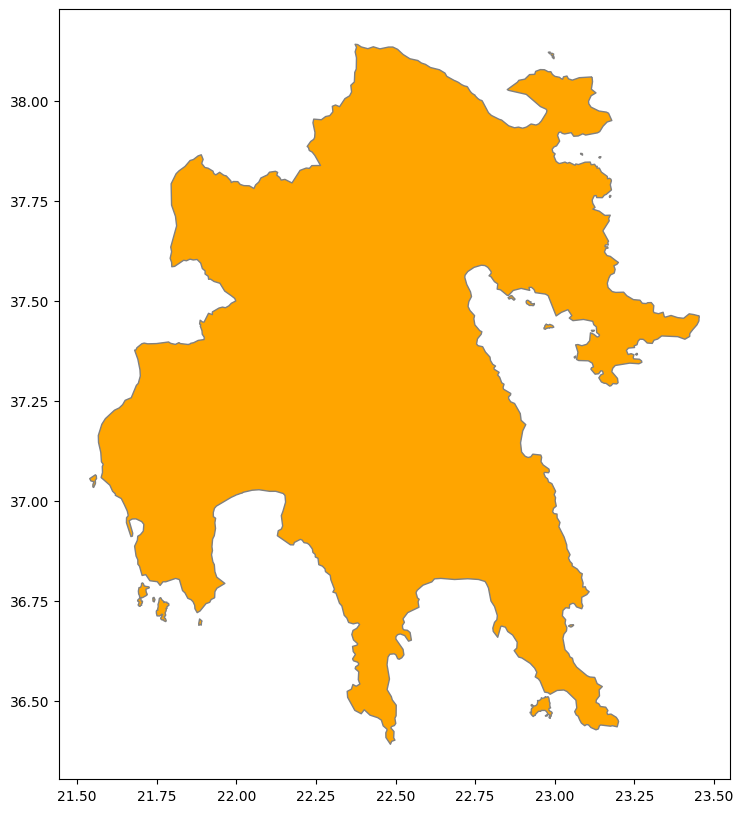

In [14]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [15]:
nuts2_gdf

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
7,EL65,EL,Peloponnisos,Πελοπόννησος,Greece,"MULTIPOLYGON (((23.11753 38.06065, 23.11906 38..."


In [16]:
nuts2_gdf.drop(columns=['CNTR_CODE','NAME_LATN','CNTR_NAME'], inplace = True)
nuts2_gdf.reset_index(drop = True, inplace = True)
process_greek(nuts2_gdf, 'NUTS_NAME')


In [17]:
nuts2_gdf.head(5)

,NUTS_ID,NUTS_NAME,geometry
0,EL65,πελοποννησος,"MULTIPOLYGON (((23.11753 38.06065, 23.11906 38..."


<Axes: >

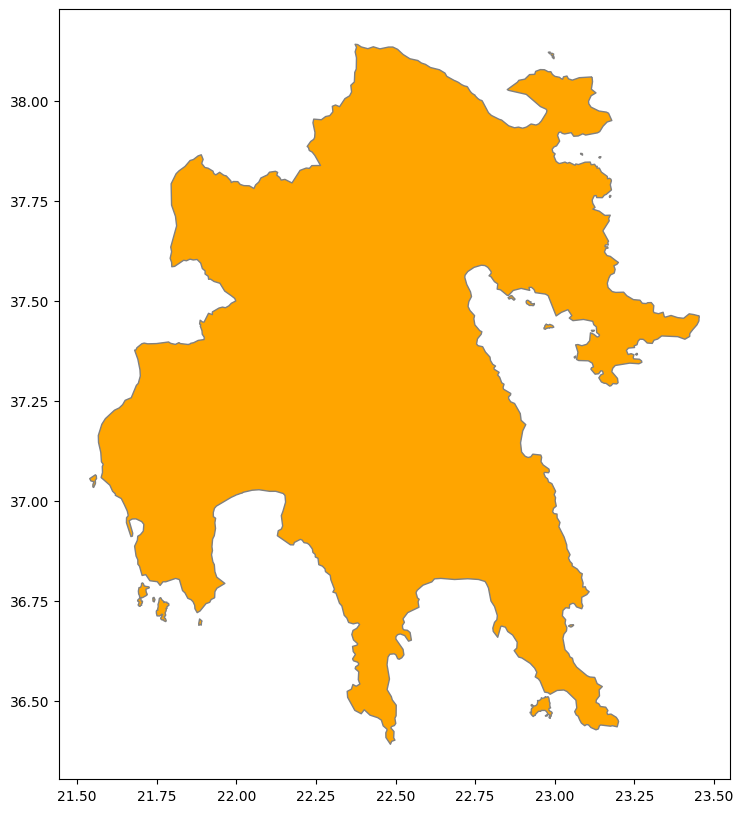

In [18]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [19]:
nuts2_gdf.reset_index(inplace=True, drop = True)

In [20]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='NUTS_ID', dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [21]:
df_grid.shape

(3565, 5)

In [22]:
df_grid.head()

,geometry,centers,NAME,x,y
0,"POLYGON ((21.60610 37.05665, 21.60610 37.07462...",POINT (21.594938712225826 37.06563193500806),EL65,21.59494,37.06563
1,"POLYGON ((21.60610 37.07462, 21.60610 37.09258...",POINT (21.594938712225826 37.083598626608264),EL65,21.59494,37.08360
2,"POLYGON ((21.60610 37.09258, 21.60610 37.11055...",POINT (21.594938712225826 37.101565318208486),EL65,21.59494,37.10157
3,"POLYGON ((21.60610 37.11055, 21.60610 37.12852...",POINT (21.594938712225826 37.119532009808694),EL65,21.59494,37.11953
4,"POLYGON ((21.60610 37.12852, 21.60610 37.14648...",POINT (21.594938712225826 37.13749870140891),EL65,21.59494,37.13750


In [23]:
df_grid.rename(columns={"NAME": "NUTS2_ID"}, inplace = True)

<Axes: >

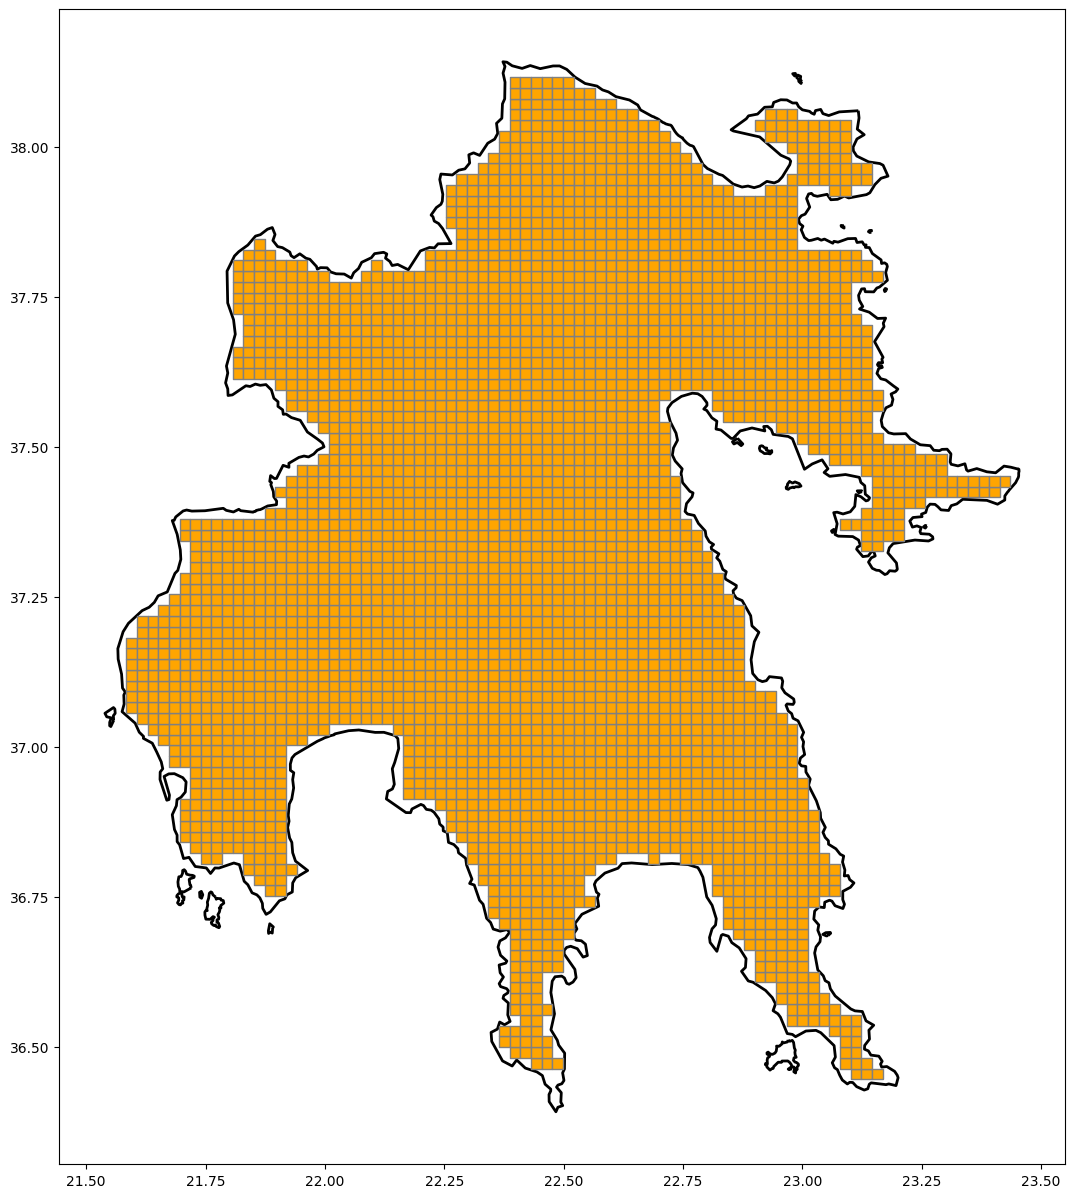

In [24]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [25]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [26]:
nuts2_grid['cell_number'] = nuts2_grid.index

In [27]:
nuts2_grid

,geometry,NUTS2_ID,x,y,cell_number
0,"POLYGON ((21.60610 37.05665, 21.60610 37.07462...",EL65,21.59494,37.06563,0
1,"POLYGON ((21.60610 37.07462, 21.60610 37.09258...",EL65,21.59494,37.08360,1
2,"POLYGON ((21.60610 37.09258, 21.60610 37.11055...",EL65,21.59494,37.10157,2
3,"POLYGON ((21.60610 37.11055, 21.60610 37.12852...",EL65,21.59494,37.11953,3
4,"POLYGON ((21.60610 37.12852, 21.60610 37.14648...",EL65,21.59494,37.13750,4
...,...,...,...,...,...
3560,"POLYGON ((23.39166 37.41598, 23.39166 37.43395...",EL65,23.38050,37.42497,3560
3561,"POLYGON ((23.39166 37.43395, 23.39166 37.45192...",EL65,23.38050,37.44293,3561
3562,"POLYGON ((23.41398 37.41598, 23.41398 37.43395...",EL65,23.40282,37.42497,3562
3563,"POLYGON ((23.41398 37.43395, 23.41398 37.45192...",EL65,23.40282,37.44293,3563


In [28]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [29]:
nuts2_grid_points

,geometry,NUTS2_ID,x,y,cell_number
0,POINT (21.59494 37.06563),EL65,21.59494,37.06563,0
1,POINT (21.59494 37.08360),EL65,21.59494,37.08360,1
2,POINT (21.59494 37.10157),EL65,21.59494,37.10157,2
3,POINT (21.59494 37.11953),EL65,21.59494,37.11953,3
4,POINT (21.59494 37.13750),EL65,21.59494,37.13750,4
...,...,...,...,...,...
3560,POINT (23.38050 37.42497),EL65,23.38050,37.42497,3560
3561,POINT (23.38050 37.44293),EL65,23.38050,37.44293,3561
3562,POINT (23.40282 37.42497),EL65,23.40282,37.42497,3562
3563,POINT (23.40282 37.44293),EL65,23.40282,37.44293,3563


<Axes: >

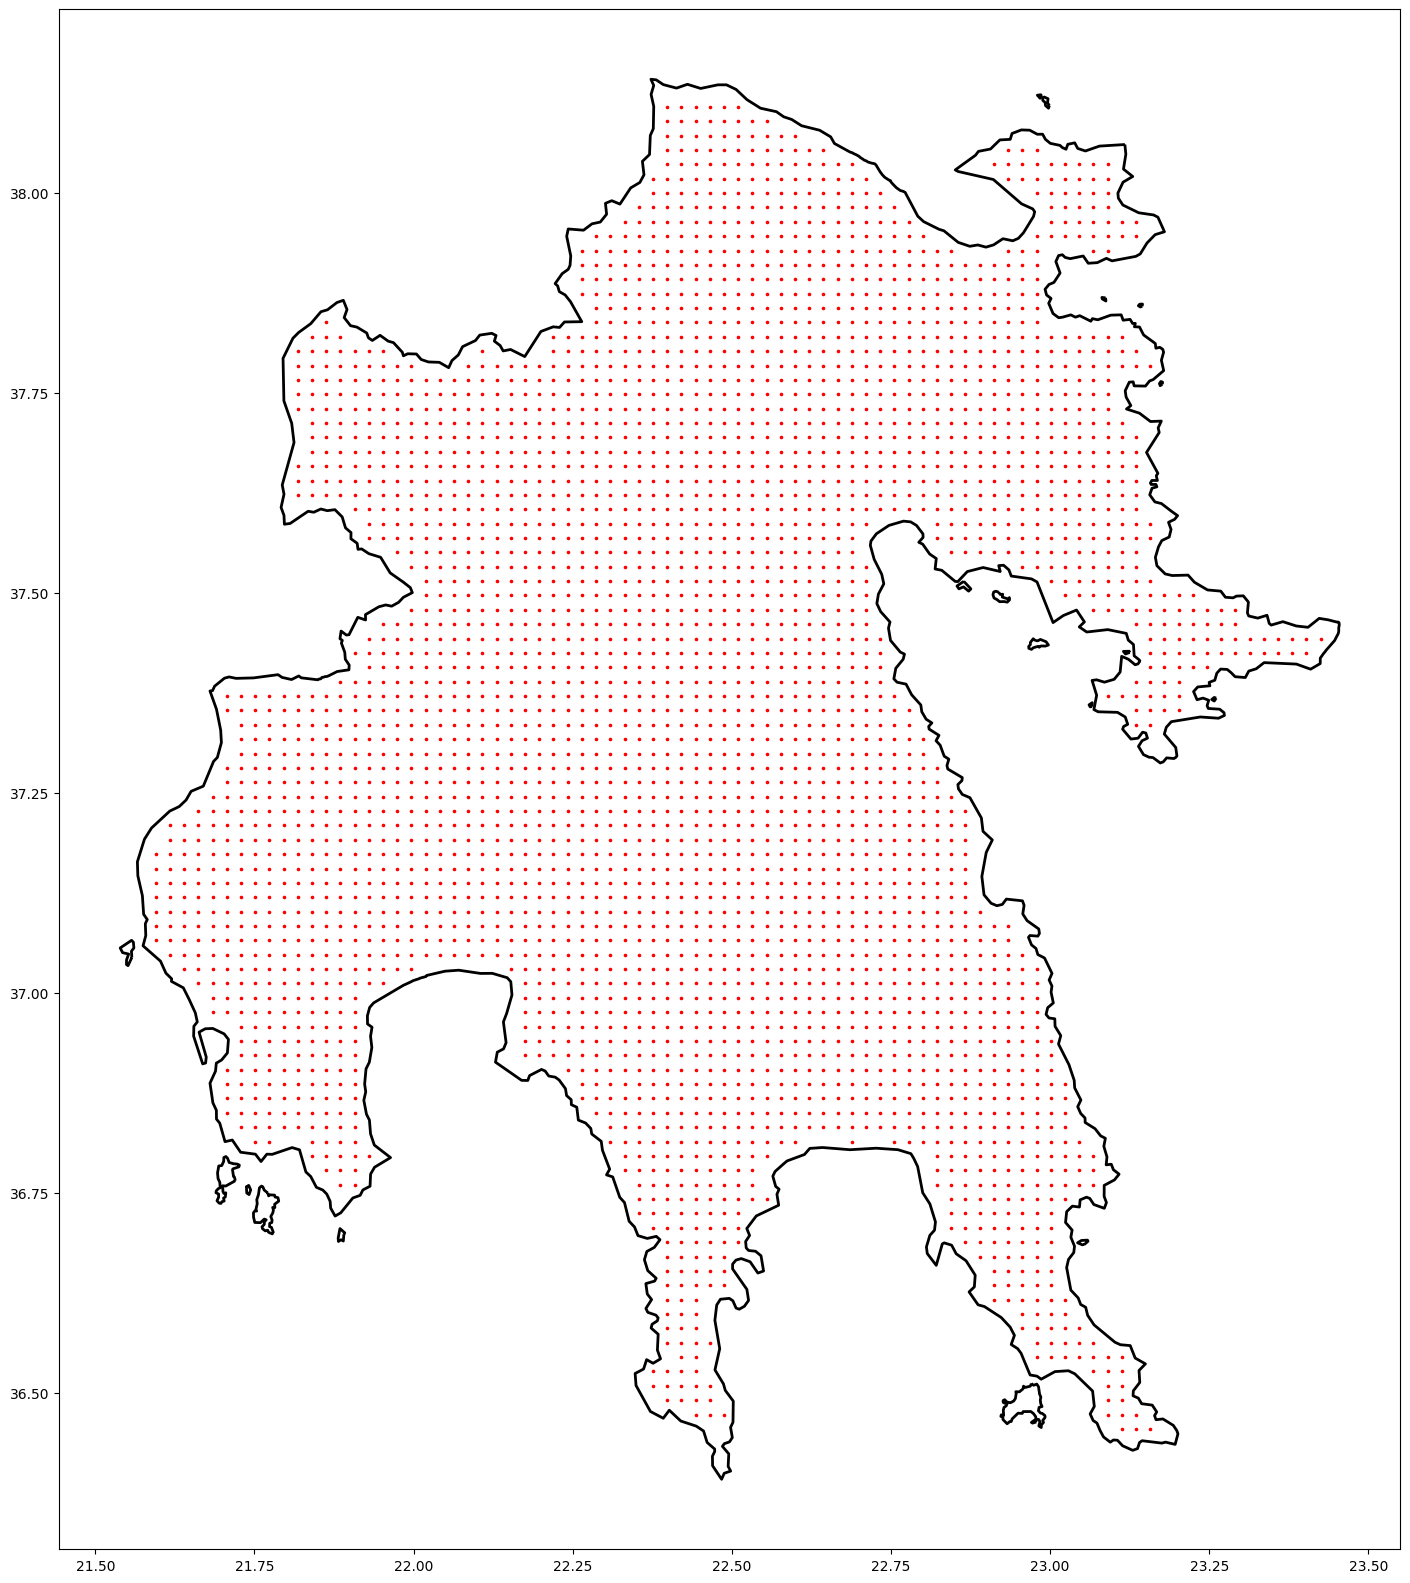

In [30]:
ax = nuts2_grid_points.plot(markersize=2.5, figsize=(20, 20), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [31]:
final_grid = nuts2_grid[['cell_number', 'NUTS2_ID', 'x', 'y', 'geometry']]

final_grid.reset_index(drop = True, inplace= True)

In [32]:
final_grid

,cell_number,NUTS2_ID,x,y,geometry
0,0,EL65,21.59494,37.06563,"POLYGON ((21.60610 37.05665, 21.60610 37.07462..."
1,1,EL65,21.59494,37.08360,"POLYGON ((21.60610 37.07462, 21.60610 37.09258..."
2,2,EL65,21.59494,37.10157,"POLYGON ((21.60610 37.09258, 21.60610 37.11055..."
3,3,EL65,21.59494,37.11953,"POLYGON ((21.60610 37.11055, 21.60610 37.12852..."
4,4,EL65,21.59494,37.13750,"POLYGON ((21.60610 37.12852, 21.60610 37.14648..."
...,...,...,...,...,...
3560,3560,EL65,23.38050,37.42497,"POLYGON ((23.39166 37.41598, 23.39166 37.43395..."
3561,3561,EL65,23.38050,37.44293,"POLYGON ((23.39166 37.43395, 23.39166 37.45192..."
3562,3562,EL65,23.40282,37.42497,"POLYGON ((23.41398 37.41598, 23.41398 37.43395..."
3563,3563,EL65,23.40282,37.44293,"POLYGON ((23.41398 37.43395, 23.41398 37.45192..."


In [33]:
final_grid.drop(columns='geometry')

,cell_number,NUTS2_ID,x,y
0,0,EL65,21.59494,37.06563
1,1,EL65,21.59494,37.08360
2,2,EL65,21.59494,37.10157
3,3,EL65,21.59494,37.11953
4,4,EL65,21.59494,37.13750
...,...,...,...,...
3560,3560,EL65,23.38050,37.42497
3561,3561,EL65,23.38050,37.44293
3562,3562,EL65,23.40282,37.42497
3563,3563,EL65,23.40282,37.44293


In [35]:
final_grid.drop(columns='geometry').to_csv(f'../../data/{NUTS2}/GR_{NUTS2}_GRID.csv', encoding=enc, index = False)

In [36]:
final_grid.to_file(f'../../data/{NUTS2}/GR_{NUTS2}_GRID.shp', encoding = 'utf-8')